### Task 1: Dataset Exploration

In [1]:
import pandas as pd

In [2]:
#  Load the dataset.
col = ["Variance", "Skewness", "Curtosis", "Entropy", 'Class']
df = pd.read_csv("/content/data_banknote_authentication.txt", header = None, names = col)

In [3]:
#  Display the first five samples.
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
#  Determine dataset dimensions.
print(df.shape)

(1372, 5)


In [5]:
#  Identify missing values.
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [6]:
#  Display descriptive statistics
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


### Task 2: Exploratory Data Analysis

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [9]:
plt.rcParams["font.family"] = "Liberation Serif"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.size"] = 12

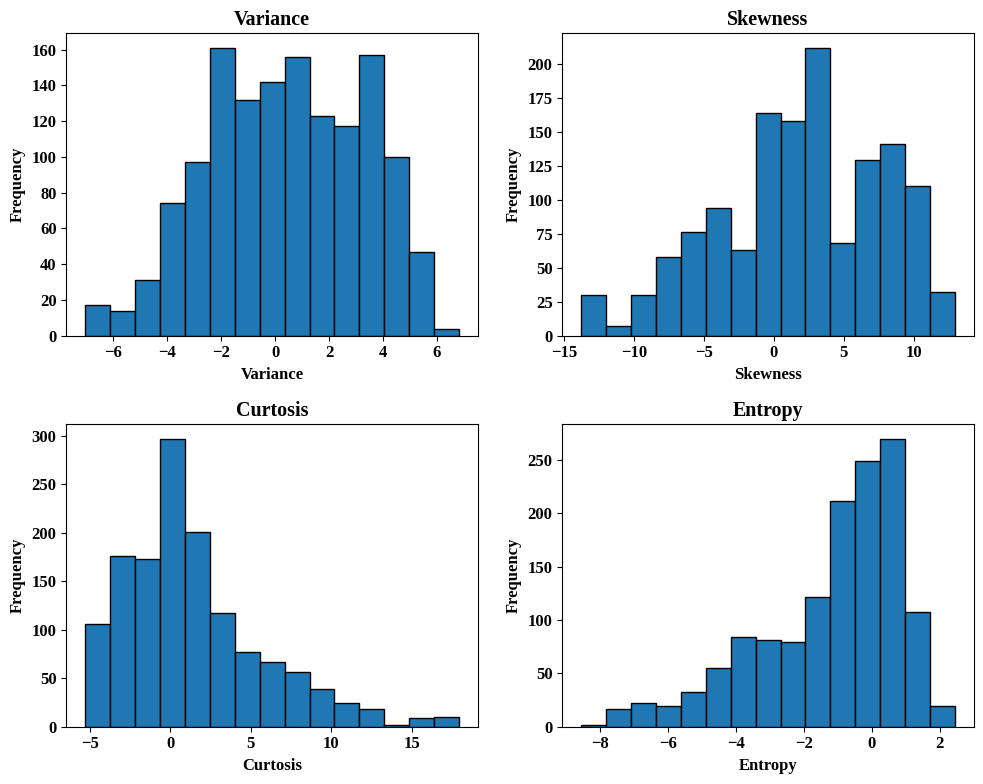

In [10]:
# Histogram

features = df.columns

fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes = axes.ravel()

for i, col in enumerate(features[:4]):
    axes[i].hist(df[col], bins=15, edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col, fontweight='bold')
    axes[i].set_ylabel("Frequency", fontweight='bold')

plt.tight_layout()

plt.savefig("Histogram_Subplots.eps", dpi=600, format="eps")

plt.show()

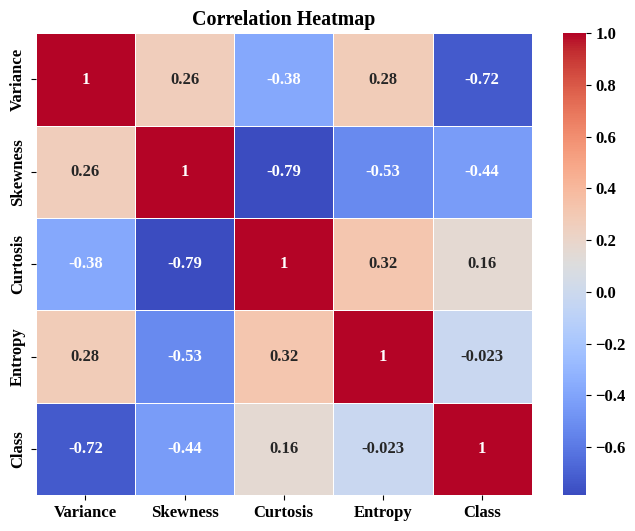

In [11]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap", fontweight="bold")
plt.savefig("Correlation_Heatmap.eps", dpi=600, format="eps")
plt.show()

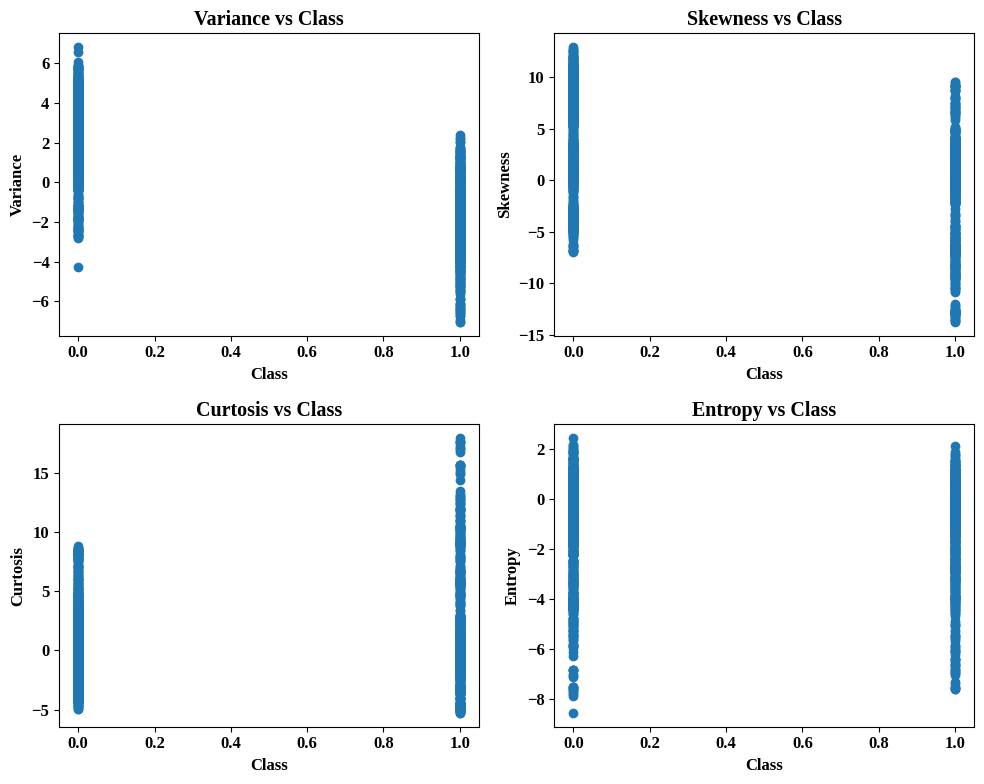

In [12]:
# Scatter Plot

fig, axes = plt.subplots(2, 2, figsize = (10, 8))

axes = axes.ravel()

for i, col in enumerate(features[:4]):
  axes[i].scatter(df["Class"], df[col])
  axes[i].set_xlabel("Class", fontweight = 'bold')
  axes[i].set_ylabel(f"{col}", fontweight = 'bold')
  axes[i].set_title(f"{col} vs Class", fontweight = 'bold')

plt.tight_layout()

plt.savefig("Scatter_Subplots.eps", dpi=600, format="eps")

plt.show()

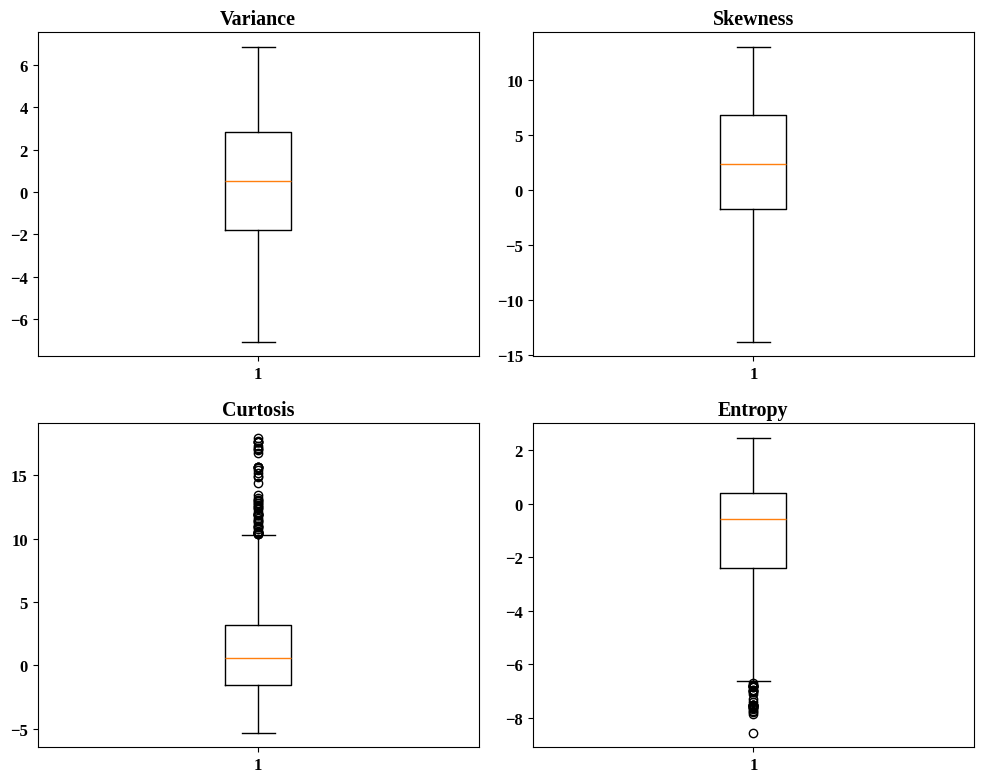

In [13]:
# Boxplot

fig, axes = plt.subplots(2,2, figsize=(10,8))

axes = axes.ravel()

for i, col in enumerate(features[:4]):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontweight="bold")

plt.tight_layout()

plt.savefig("Boxplots.eps", dpi=600, format="eps")

plt.show()

### Task 3: Data Preprocessing

In [14]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [15]:
# Separate Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [16]:
#  Split the dataset into Training (80%) and Testing (20%).

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [17]:
# Normalize all numerical features.

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Display Shapes
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1097, 4)
Testing Features  : (275, 4)
Training Labels   : (1097,)
Testing Labels    : (275,)


### Task 4: Perceptron Implementation

In [19]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=100):
        """
        Constructor

        Parameters:
        learning_rate : Learning rate (η)
        epochs        : Number of iterations over the dataset
        """

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def _step_function(self, z):
        """
        Step Activation Function
        """

        if z >= 0:
            return 1
        else:
            return 0

    def fit(self, X, y):
        """
        Train the Perceptron
        """

        n_samples, n_features = X.shape

        # Initialize history lists
        self.misclassified_history = []
        self.weights_history = []
        self.bias_history = []

        # Weight Initialization
        self.weights = np.zeros(n_features)

        # Bias Initialization
        self.bias = 0

        misclassified_samples = []

        print("Perceptron Training\n")

        # Training
        for epoch in range(self.epochs):

            for i in range(n_samples):
                x = X[i]
                target = y.iloc[i]

                # Forward Propagation
                z = np.dot(self.weights, x) + self.bias
                prediction = self._step_function(z)

                # Error
                error = target - prediction

                # Misclassified Samples
                if (error != 0):
                    misclassified_samples.append(i)

                # Update Rule
                self.weights += self.learning_rate * error * x
                self.bias += self.learning_rate * error

            # Store history for the current epoch
            self.misclassified_history.append(len(misclassified_samples))
            self.weights_history.append(self.weights.copy()) # Append a copy to avoid modification issues
            self.bias_history.append(self.bias)

            # Printing weights, biases & misclassified samples
            print(f"Epoch {epoch + 1}:")
            print(f"\tUpdated Weights: {self.weights}")
            print(f"\tUpdated Bias: {self.bias}")
            print(f"\tMisclassified Samples: {misclassified_samples}\n")

            # Early Stopping
            if len(misclassified_samples) == 0:
                print("\nTraining Complete (Converged)")
                break

            misclassified_samples.clear()

    def predict(self, X):
        """
        Predict labels for multiple samples
        """

        predictions = []

        for x in X:
            z = np.dot(self.weights, x) + self.bias
            predictions.append(self._step_function(z))

        return np.array(predictions)

    def predict_single(self, x):
        """
        Predict one sample
        """

        z = np.dot(self.weights, x) + self.bias
        return self._step_function(z)

    def score(self, X, y):
        """
        Calculate Accuracy
        """

        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        return accuracy

### Task 5: Model Training

In [20]:
# Create model
model = Perceptron(learning_rate = 0.01, epochs = 100)

In [21]:
# Training
model.fit(X_train, y_train)

Perceptron Training

Epoch 1:
	Updated Weights: [-0.07006804 -0.04079083 -0.05334423  0.02214898]
	Updated Bias: 0.08
	Misclassified Samples: [0, 2, 5, 6, 7, 8, 10, 12, 16, 18, 19, 20, 21, 24, 31, 37, 43, 48, 52, 56, 60, 74, 75, 79, 80, 81, 83, 101, 102, 103, 104, 105, 110, 111, 121, 122, 138, 139, 142, 143, 147, 148, 151, 152, 159, 163, 164, 167, 171, 173, 178, 180, 181, 185, 187, 194, 195, 215, 217, 231, 237, 243, 244, 251, 252, 259, 269, 277, 280, 283, 287, 292, 300, 303, 304, 305, 306, 312, 316, 324, 326, 327, 344, 346, 355, 358, 369, 371, 415, 417, 418, 419, 427, 428, 430, 432, 440, 449, 450, 457, 458, 462, 464, 465, 466, 478, 483, 489, 492, 503, 504, 534, 540, 591, 592, 593, 598, 605, 606, 611, 615, 621, 627, 643, 644, 647, 648, 651, 654, 655, 699, 703, 744, 753, 761, 762, 784, 788, 809, 811, 813, 814, 835, 836, 867, 868, 875, 877, 879, 884, 890, 896, 933, 948, 950, 952, 953, 959, 963, 970, 972, 976, 977, 1047, 1052, 1071, 1072, 1092]

Epoch 2:
	Updated Weights: [-0.08719187 -0.0

In [22]:
# Testing
y_pred = model.predict(X_test)

In [23]:
# Accuracy
print("Accuracy: ", model.score(X_test, y_test))

Accuracy:  0.9854545454545455


### Task 6: Model Evaluation

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Display metrics
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

Accuracy  : 0.9855
Precision : 0.9843
Recall    : 0.9843
F1-Score  : 0.9843

Confusion Matrix
[[146   2]
 [  2 125]]


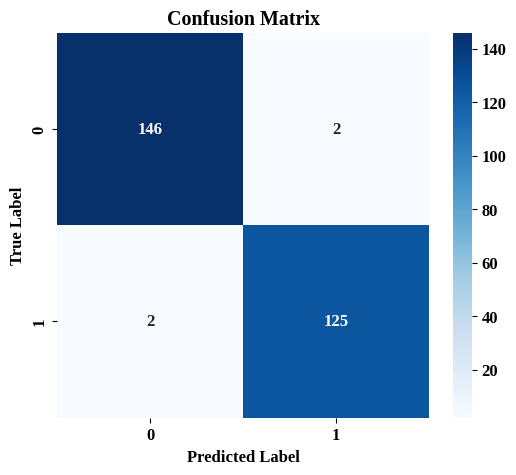

In [26]:
# Plotting the confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig('Confusion_Matrix.eps', dpi=600, format='eps')
plt.show()

### Task 7: Analyzing Perceptron Learning Process

This section introduces a series of visualizations designed to provide a deeper understanding of the Perceptron model's learning dynamics. We will examine:

*   **Training Error vs Epoch**: How the number of misclassified samples changes over each training epoch.
*   **Weight Evolution**: The progression of each feature's weight throughout the training process.
*   **Bias Evolution**: The adjustment of the model's bias term across epochs.
*   **Learning Rate Comparison**: The impact of different learning rates on the model's convergence.

These plots will help us analyze the model's convergence behavior, the stability of its parameters, and the influence of hyperparameters on its performance.
```

## Plot Training Error vs Epoch


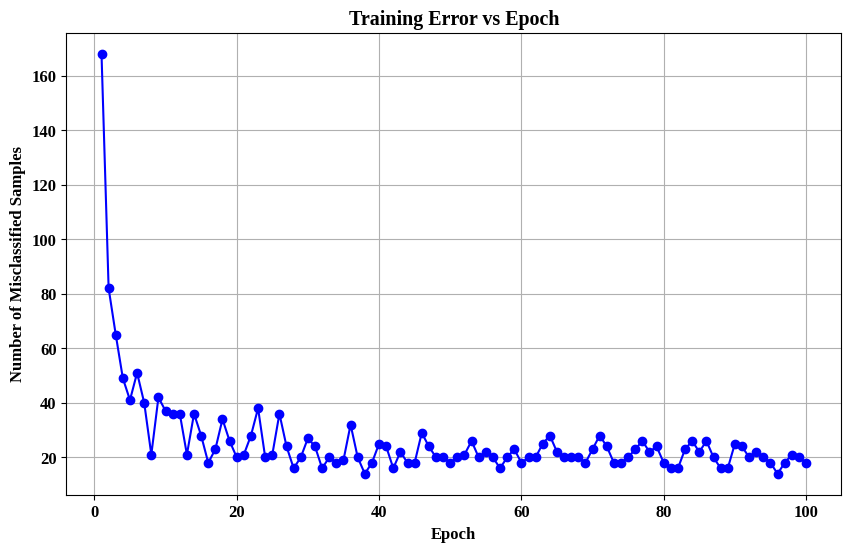

In [27]:
# Access the misclassified_history from the model object
misclassified_samples_per_epoch = model.misclassified_history

# Create a list of epoch numbers
epochs = range(1, len(misclassified_samples_per_epoch) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, misclassified_samples_per_epoch, marker='o', linestyle='-', color='blue')

# Add labels and title
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Number of Misclassified Samples', fontweight='bold')
plt.title('Training Error vs Epoch', fontweight='bold')
plt.grid(True)

# Save the plot
plt.savefig('Training_Error_vs_Epoch.eps', dpi=600, format='eps')

# Display the plot
plt.show()

## Plot Weight Evolution

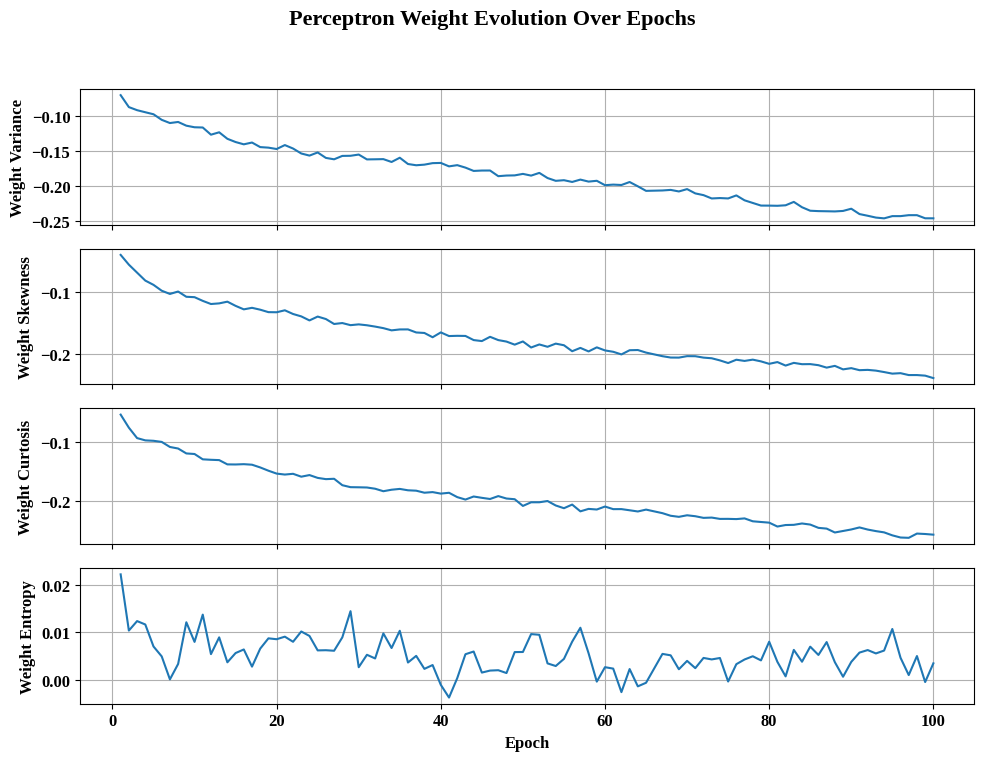

In [28]:
weights_history = np.array(model.weights_history)
epochs = range(1, len(weights_history) + 1)
n_features = weights_history.shape[1]

fig, axes = plt.subplots(n_features, 1, figsize=(10, 2 * n_features), sharex=True)
fig.suptitle('Perceptron Weight Evolution Over Epochs', fontweight='bold', fontsize=16)

feature_names = df.columns[:-1] # Assuming the last column is 'Class'

for i in range(n_features):
    axes[i].plot(epochs, weights_history[:, i], label=f'Weight {feature_names[i]}')
    axes[i].set_ylabel(f'Weight {feature_names[i]}', fontweight='bold')
    axes[i].grid(True)

axes[-1].set_xlabel('Epoch', fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Weight_Evolution.eps', dpi=600, format='eps')
plt.show()

## Plot Bias Evolution

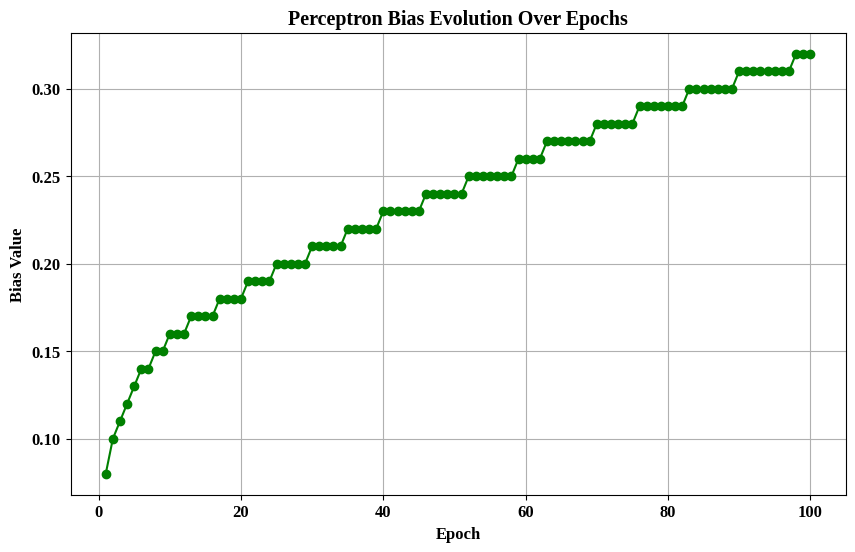

In [29]:
bias_history = model.bias_history
epochs = range(1, len(bias_history) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, bias_history, marker='o', linestyle='-', color='green')

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Bias Value', fontweight='bold')
plt.title('Perceptron Bias Evolution Over Epochs', fontweight='bold')
plt.grid(True)

plt.savefig('Bias_Evolution.eps', dpi=600, format='eps')
plt.show()

## Plot Learning Rate Comparison


In [30]:
learning_rates = [0.001, 0.01, 0.1]
all_misclassified_histories = []

for lr in learning_rates:
    print(f"\nTraining Perceptron with Learning Rate: {lr}")
    model_lr = Perceptron(learning_rate=lr, epochs=100)
    model_lr.fit(X_train, y_train)
    all_misclassified_histories.append(model_lr.misclassified_history)



Training Perceptron with Learning Rate: 0.001
Perceptron Training

Epoch 1:
	Updated Weights: [-0.0070068  -0.00407908 -0.00533442  0.0022149 ]
	Updated Bias: 0.008
	Misclassified Samples: [0, 2, 5, 6, 7, 8, 10, 12, 16, 18, 19, 20, 21, 24, 31, 37, 43, 48, 52, 56, 60, 74, 75, 79, 80, 81, 83, 101, 102, 103, 104, 105, 110, 111, 121, 122, 138, 139, 142, 143, 147, 148, 151, 152, 159, 163, 164, 167, 171, 173, 178, 180, 181, 185, 187, 194, 195, 215, 217, 231, 237, 243, 244, 251, 252, 259, 269, 277, 280, 283, 287, 292, 300, 303, 304, 305, 306, 312, 316, 324, 326, 327, 344, 346, 355, 358, 369, 371, 415, 417, 418, 419, 427, 428, 430, 432, 440, 449, 450, 457, 458, 462, 464, 465, 466, 478, 483, 489, 492, 503, 504, 534, 540, 591, 592, 593, 598, 605, 606, 611, 615, 621, 627, 643, 644, 647, 648, 651, 654, 655, 699, 703, 744, 753, 761, 762, 784, 788, 809, 811, 813, 814, 835, 836, 867, 868, 875, 877, 879, 884, 890, 896, 933, 948, 950, 952, 953, 959, 963, 970, 972, 976, 977, 1047, 1052, 1071, 1072, 109

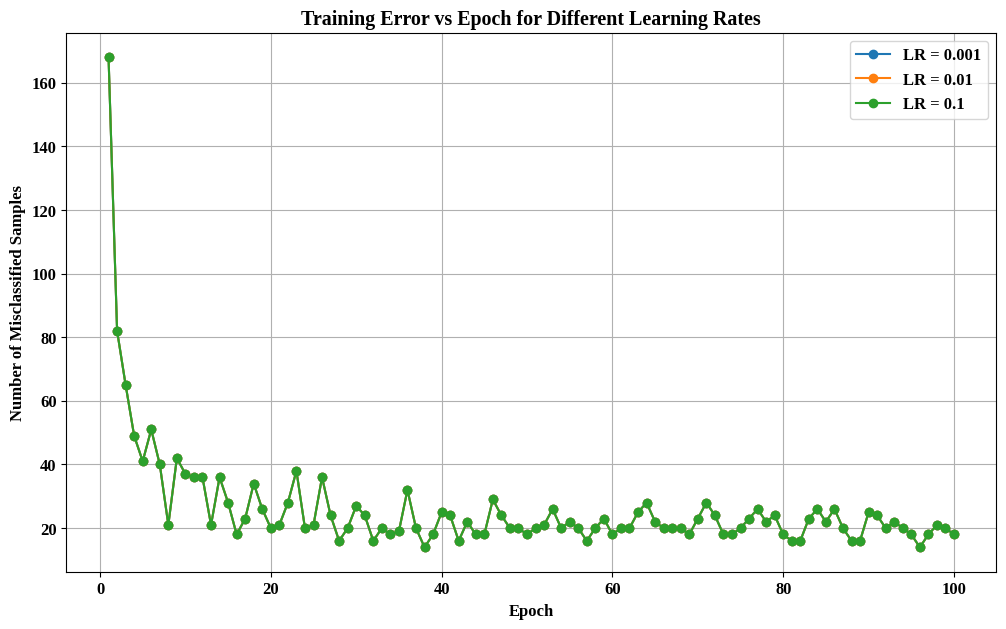

In [31]:
plt.figure(figsize=(12, 7))

for i, history in enumerate(all_misclassified_histories):
    epochs = range(1, len(history) + 1)
    plt.plot(epochs, history, marker='o', linestyle='-', label=f'LR = {learning_rates[i]}')

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Number of Misclassified Samples', fontweight='bold')
plt.title('Training Error vs Epoch for Different Learning Rates', fontweight='bold')
plt.legend()
plt.grid(True)

plt.savefig('Learning_Rate_Comparison.eps', dpi=600, format='eps')
plt.show()

#### Logic Gates using Perceptron

##### Import Libraries


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Dataset Creation

In [33]:
# AND gate
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
Y_and = pd.Series([0,0,0,1])

In [34]:
# OR gate
X_or = np.array([[0,0], [0,1], [1,0], [1,1]])
Y_or = pd.Series([0,1,1,1])

In [35]:
# NOT gate
X_not = np.array([[0], [1]])
Y_not = pd.Series([1,0])

In [36]:
# XOR gate
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
Y_xor = pd.Series([0,1,1,0])

##### Plot Decision Boundary

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, weights, bias, gate_name, epoch):

    plt.figure(figsize=(6, 6))

    # Plot Class 0
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        color="red",
        marker="o",
        s=80,
        label="Class 0"
    )

    # Plot Class 1
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color="blue",
        marker="^",
        s=80,
        label="Class 1"
    )

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    w1, w2 = weights

    # -----------------------------
    # Decision Boundary
    # -----------------------------

    eps = 1e-10

    if abs(w1) < eps and abs(w2) < eps:

        # No meaningful separator
        pass

    elif abs(w2) < eps:

        # Vertical line
        x = -bias / w1
        plt.axvline(
            x=x,
            color="black",
            linewidth=2,
            label="Decision Boundary"
        )

    elif abs(w1) < eps:

        # Horizontal line
        y_line = -bias / w2
        plt.axhline(
            y=y_line,
            color="black",
            linewidth=2,
            label="Decision Boundary"
        )

    else:

        x = np.linspace(x_min, x_max, 200)
        y_line = -(w1 * x + bias) / w2

        plt.plot(
            x,
            y_line,
            color="black",
            linewidth=2,
            label="Decision Boundary"
        )

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.xlabel("Input 1")
    plt.ylabel("Input 2")

    plt.title(f"{gate_name} Gate - Epoch {epoch}")

    plt.grid(True)
    plt.legend()

    plt.show()

##### AND Gate training along with Decision Boundary plot after each Epoch

Perceptron Training

Epoch 1:
	Updated Weights: [1. 1.]
	Updated Bias: 0
	Misclassified Samples: [0, 3]

Epoch 2:
	Updated Weights: [2. 1.]
	Updated Bias: -1
	Misclassified Samples: [0, 1, 3]

Epoch 3:
	Updated Weights: [2. 1.]
	Updated Bias: -2
	Misclassified Samples: [1, 2, 3]

Epoch 4:
	Updated Weights: [2. 2.]
	Updated Bias: -2
	Misclassified Samples: [2, 3]

Epoch 5:
	Updated Weights: [2. 1.]
	Updated Bias: -3
	Misclassified Samples: [1]

Epoch 6:
	Updated Weights: [2. 1.]
	Updated Bias: -3
	Misclassified Samples: []


Training Complete (Converged)


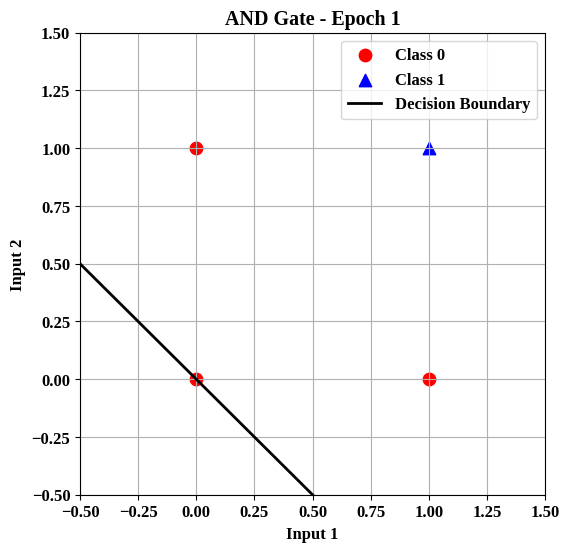

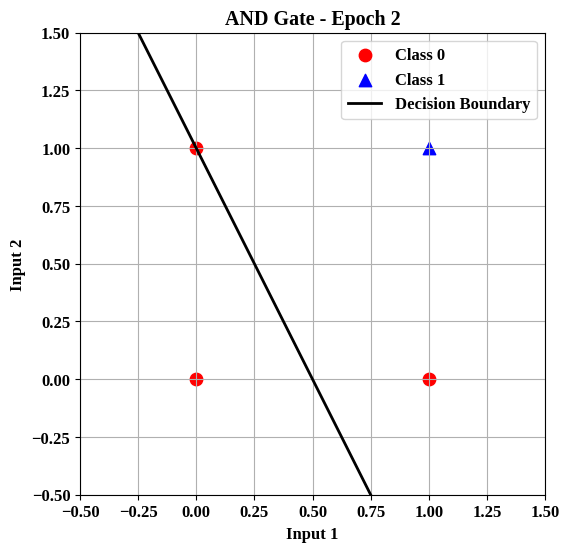

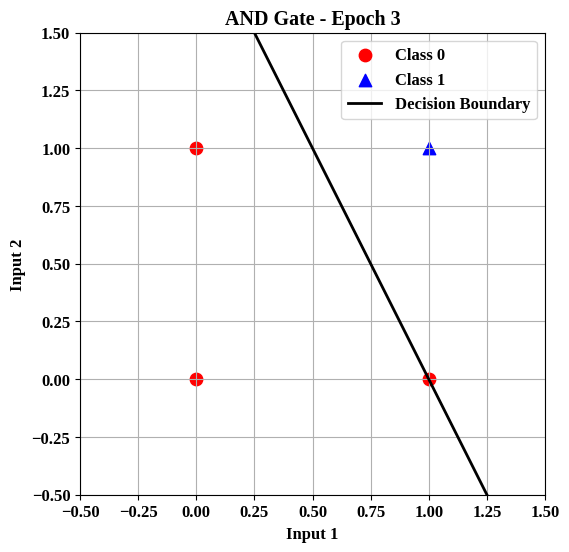

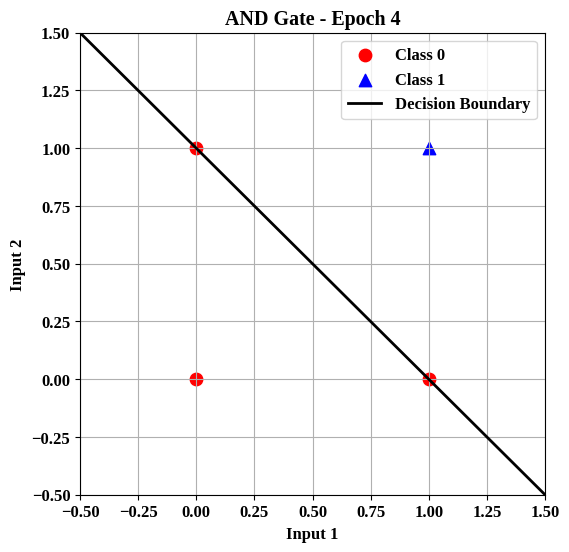

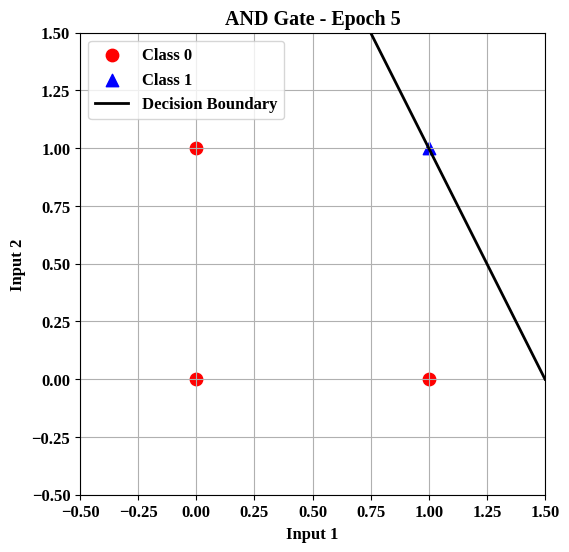

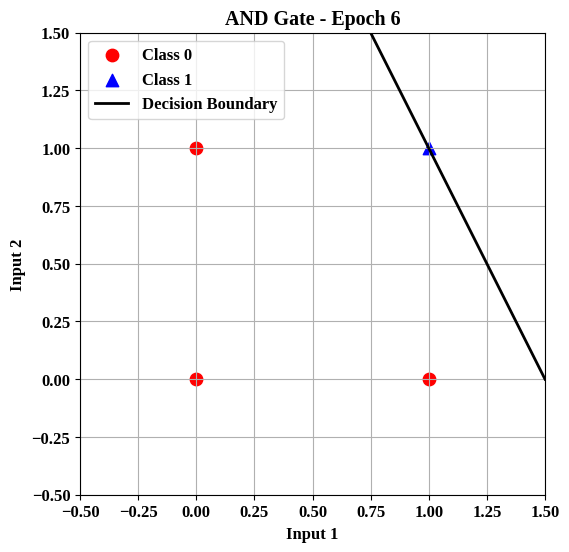

In [38]:
model_and = Perceptron(learning_rate = 1, epochs = 10)
model_and.fit(X_and, Y_and)

for i in range(len(model_and.weights_history)):

    model_and.weights = model_and.weights_history[i]
    model_and.bias = model_and.bias_history[i]

    plot_decision_boundary(
        X_and,
        Y_and,
        model_and.weights,
        model_and.bias,
        "AND",
        i + 1
    )

##### OR Gate training along with Decision Boundary plot after each Epoch

Perceptron Training

Epoch 1:
	Updated Weights: [0. 1.]
	Updated Bias: 0
	Misclassified Samples: [0, 1]

Epoch 2:
	Updated Weights: [1. 1.]
	Updated Bias: 0
	Misclassified Samples: [0, 2]

Epoch 3:
	Updated Weights: [1. 1.]
	Updated Bias: -1
	Misclassified Samples: [0]

Epoch 4:
	Updated Weights: [1. 1.]
	Updated Bias: -1
	Misclassified Samples: []


Training Complete (Converged)


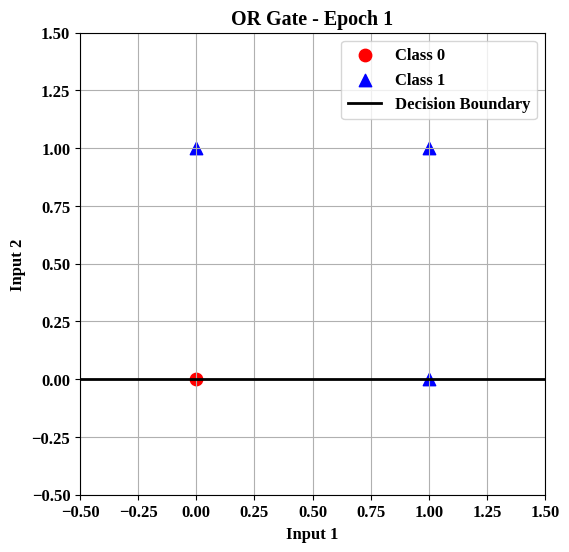

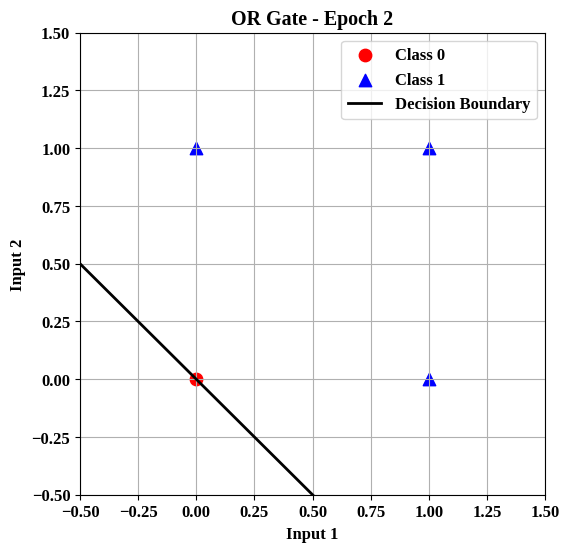

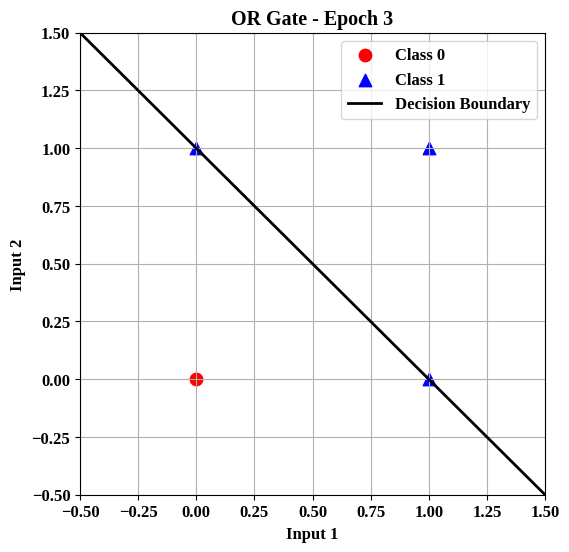

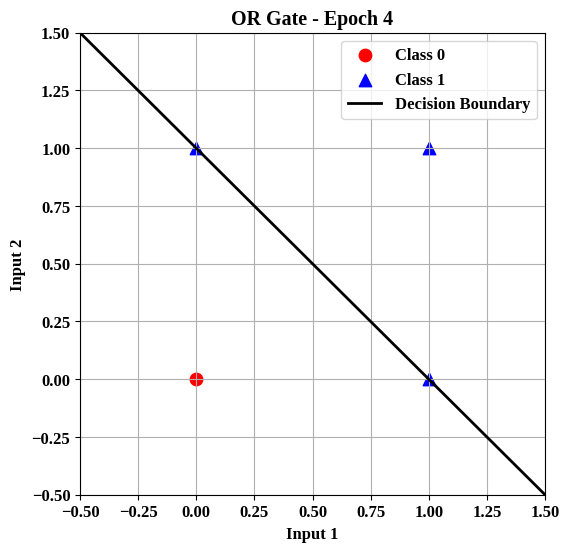

In [39]:
model_or = Perceptron(learning_rate = 1, epochs = 10)
model_or.fit(X_or, Y_or)

for i in range(len(model_or.weights_history)):

    model_or.weights = model_or.weights_history[i]
    model_or.bias = model_or.bias_history[i]

    plot_decision_boundary(
        X_or,
        Y_or,
        model_or.weights,
        model_or.bias,
        "OR",
        i + 1
    )

##### NOT Gate training

In [40]:
model_not = Perceptron(learning_rate = 1, epochs = 10)
model_not.fit(X_not, Y_not)

Perceptron Training

Epoch 1:
	Updated Weights: [-1.]
	Updated Bias: -1
	Misclassified Samples: [1]

Epoch 2:
	Updated Weights: [-1.]
	Updated Bias: 0
	Misclassified Samples: [0]

Epoch 3:
	Updated Weights: [-1.]
	Updated Bias: 0
	Misclassified Samples: []


Training Complete (Converged)


##### XOR Gate training along with Decision Boundary plot after each Epoch

Perceptron Training

Epoch 1:
	Updated Weights: [-1.  0.]
	Updated Bias: -1
	Misclassified Samples: [0, 1, 3]

Epoch 2:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [1, 2, 3]

Epoch 3:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]

Epoch 4:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]

Epoch 5:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]

Epoch 6:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]

Epoch 7:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]

Epoch 8:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]

Epoch 9:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]

Epoch 10:
	Updated Weights: [-1.  0.]
	Updated Bias: 0
	Misclassified Samples: [0, 1, 2, 3]



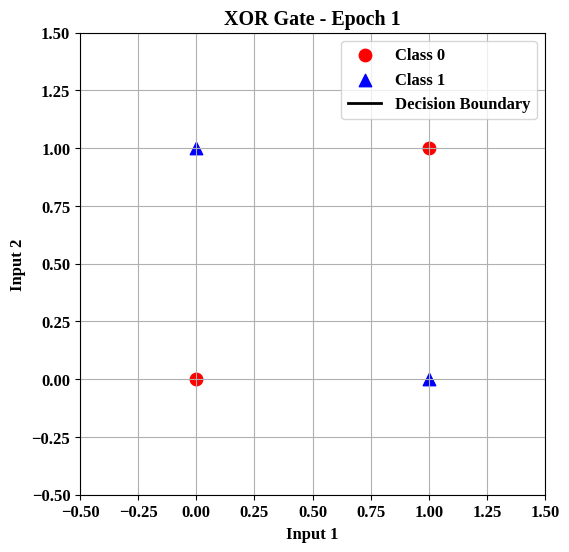

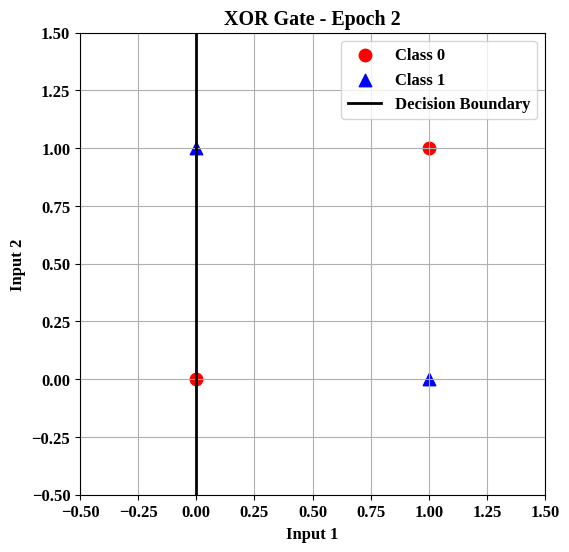

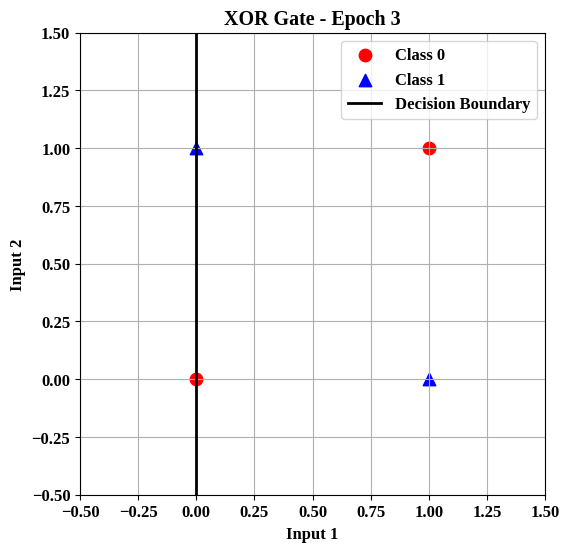

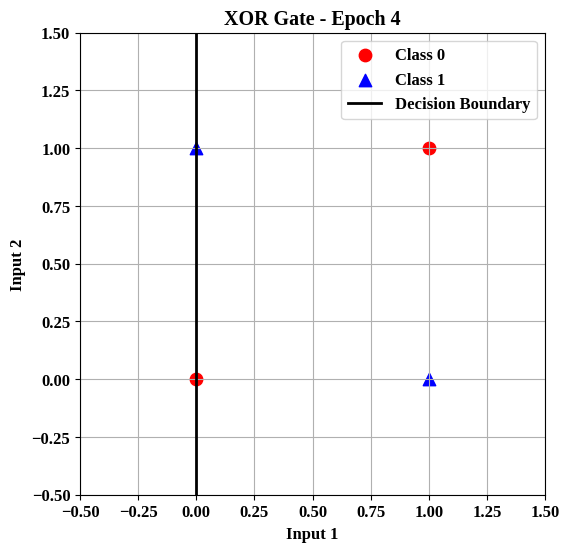

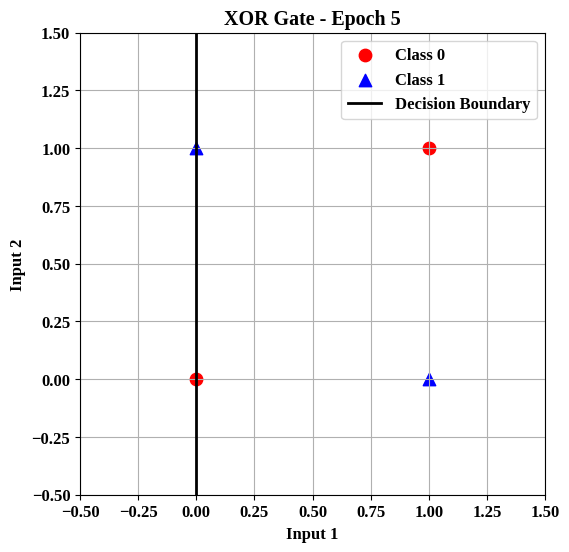

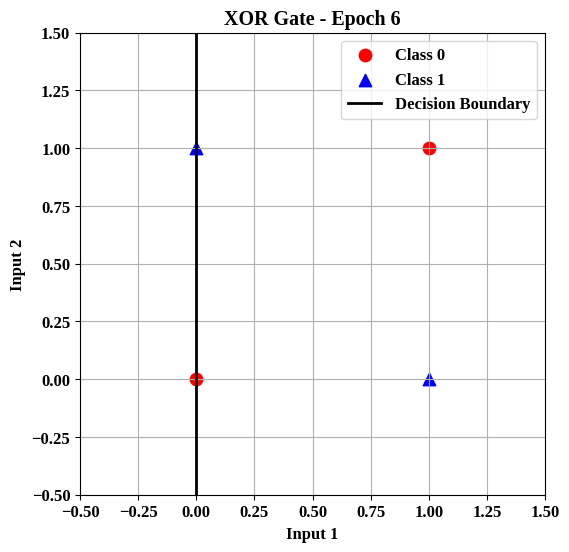

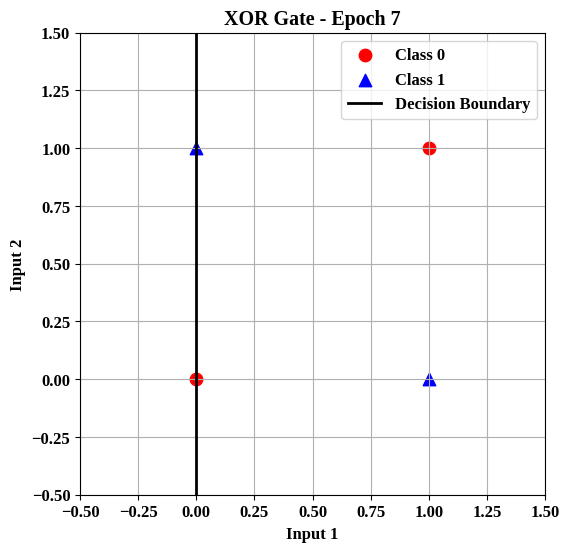

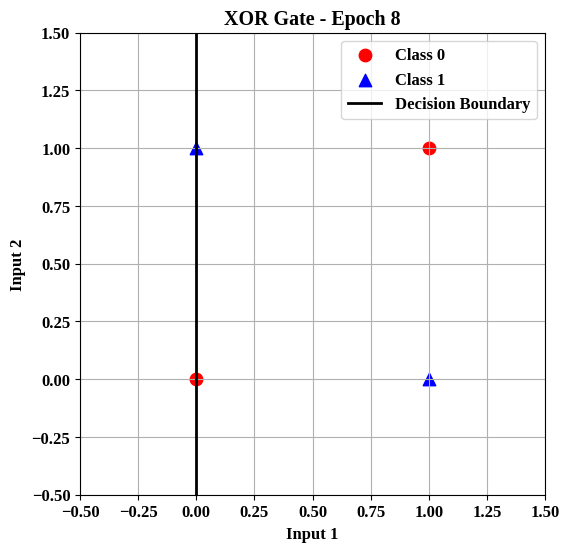

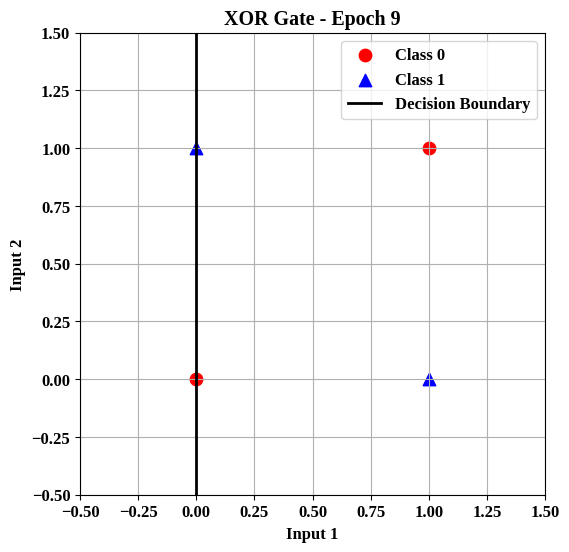

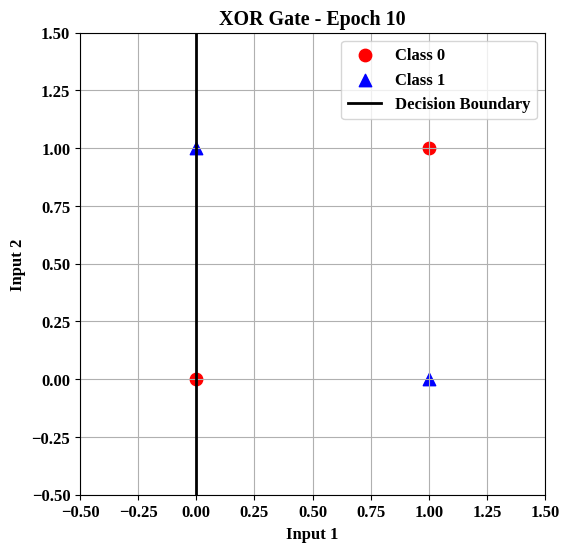

In [42]:
model_xor = Perceptron(learning_rate = 1, epochs = 10)
model_xor.fit(X_xor, Y_xor)

for i in range(len(model_xor.weights_history)):

    model_xor.weights = model_xor.weights_history[i]
    model_xor.bias = model_xor.bias_history[i]

    plot_decision_boundary(
        X_xor,
        Y_xor,
        model_xor.weights,
        model_xor.bias,
        "XOR",
        i + 1
    )